# Asymptotic Likelihood Ratio and Hypothesis Testing

(For reference: https://arxiv.org/pdf/1007.1727)

In high energy physics we often deal with discovery signals that we have to statistically verify. To understand this consider an experiment where we are searching for a new particle. You expect to observe both signal and background where the expected signal yield from your reference theory is $s$ while your background strength is $b$. Of course your theory can be wrong so we need to make sure there is a $\mu$ scale, so that when it is 0 we can say that the background only hypothesis prevails, while when it is 1 we say that the theory is correct (more than one is contribution of extra effects not there in your theory like perhaps something beyond standard model). Your total expected count becomes,

$$\text{Expected Count} = \mu s + b$$

Now the observed number of event is $n$, which should follow a Poisson distribution,

$$n\sim \text{Poisson}(\mu s+b)$$

This region where the signal appears is your signal region (SR). Usually we do not know the background properly, so what we do is, away from the signal region (think of any region outside the signal band) we define a control region (CR) in the data to estimate the background. This control region count, however, can be different from the signal region background expectation because CR and SR can be of different size. The CR count would then follow another Poisson distribution,

$$m\sim \text{Poisson}(\tau b)$$

where $\tau$ is the scale factor between CR and SR which luckily is known in an experiment. In this case then the total likelihood (where $s$ is known from theory) is given by,

$$L(\mu,b) = P(n|\mu s+b)P(m|\tau b) = \frac{(\mu s+b)^n}{n!}e^{-(\mu s+b)}\cdot\frac{(\tau b)^m}{m!}e^{-\tau b}$$

The parameter of interest here is $\mu$, where $b$ is a nuisance parameter which we don't care about. You might note now that any signal hypothesis will have dependence on $b$ so we cannot really ignore it to get the best fit for $\mu$. But then how do we quantify how far our $\mu=\text{some constant}$ hypothesis is from the best fit? Well, for this fixed value of $\mu$, there must exist a maximum likelihood estimate for $b$ given by $\hat{\hat{b}}(\mu)$ that best explains the data, then in the log likelihood space the difference between the corresponding likelihood and the global maximum, where we let both $\mu$ and $b$ vary to get $(\hat{\mu},\hat{b})$ should tell us if our "$\mu=\text{some constant}$" hypothesis is correct and if not then by what significance it fails. We define the profile likelihood ratio,

$$\lambda(\mu) = \frac{L(\mu,\hat{\hat{b}})}{L(\hat{\mu},\hat{b})}$$

and the test statistics from Neyman-Pearson lemma,

$$q_\mu = -2\ln\lambda(\mu)$$

Your first task now is to build this likelihood! To do that consider the following MLE values,

$$\begin{aligned}\hat{\mu}&=\frac{n-m/\tau}{s},\\ \hat{b}&=\frac{m}{\tau},\\ \hat{\hat{b}} &=\frac{n+m-(1+\tau)\mu s}{2(1+\tau)}+\left[\frac{(n+m-(1+\tau)\mu s)^2+4(1+\tau)m\mu s}{4(1+\tau)^2}\right]^{1/2}\end{aligned}$$

Calculate these in the next block and then write the test statistics function.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import chi2
from iminuit import Minuit

In [2]:
def mu_hat(n,m,s,tau):
    return (n - m/tau)/s

def b_hat(m,tau):
    return m/tau

def b_hat_hat(n,m,s,mu,tau):
    first_term = (n + m - (1 + tau) * mu * s)/(2 * (1 + tau))
    second_term = m * mu * s / (1 + tau)
    return first_term + (first_term ** 2 + second_term) ** 0.5

Now with that defined, try to calculate the constrained and the global log likelihoods!

In [3]:
def constrained_loglikelihood(mu,n,m,s,tau):
    b_hh = b_hat_hat(n,m,s,mu,tau)
    term1 = n * np.log(mu * s + b_hh) - (mu * s + b_hh)
    term2 = m * np.log(tau * b_hh) - (tau * b_hh)
    return term1 + term2

def global_loglikelihood(n,m,s,tau):
    mu_h = mu_hat(n,m,s,tau)
    b_h = b_hat(m,tau)
    term1 = n * np.log(mu_h * s + b_h) - (mu_h * s + b_h)
    term2 = m * np.log(tau * b_h) - (tau * b_h)
    return term1 + term2

Great write the test statistics function $q_\mu$.

In [4]:
def test_statistics(mu,n,m,s,tau):
    return -2 * (constrained_loglikelihood(mu,n,m,s,tau) - global_loglikelihood(n,m,s,tau))

## Discovery Like Scenarios $(\mu=0)$

Lets say we want to test for a discovery signal. That means we are testing for the $\mu=0$ hypothesis. One caveat that you should keep in mind is that if $\hat{mu} < 0$ then you found fewever than expected events predicted by the background, but this is neither a discovery nor a statement that the background hypothesis is correct, so the test statistics here must become zero (center of two hypothesis)! We write the full test statistics,

$$q_0 = \begin{cases} - 2\ln\lambda(0) & \hat{\mu}\geq 0\\ 0 & \hat{\mu}<0\end{cases}$$

Now use our previous definition of test statistics to write the discovery statistics.

In [5]:
def discovery_statistics(n,m,s,tau):
    test_stat = test_statistics(0,n,m,s,tau)
    mu_h = mu_hat(n,m,s,tau)
    test_stat[mu_h < 0] = 0
    return test_stat

Now lets say you have done the same experiment 100000 times, with expected background count $b=2000$, $\tau=1$, expected signal count $s=30$. Consider the case that $\mu=0$ and generate samples for the signal region and the background region. Remember $n$ corresponds to counts in SR while $m$ to counts in CR.

In [6]:
nexp = 100000
b = 2000
tau = 1
s = 30
mu = 0

mean_CR = b * tau  # Poisson mean for the CR
mean_SR = mu*s + b        # Poisson mean for the SR

# Generate Poisson-distributed data
n = np.random.poisson(mean_SR, size=nexp)  # Data set 1: mean = b * tau
m = np.random.poisson(mean_CR, size=nexp)  # Data set 2: mean = b

Now use your discover statistics calculate an array of 10000 $q_0$ values and plot their distribution!

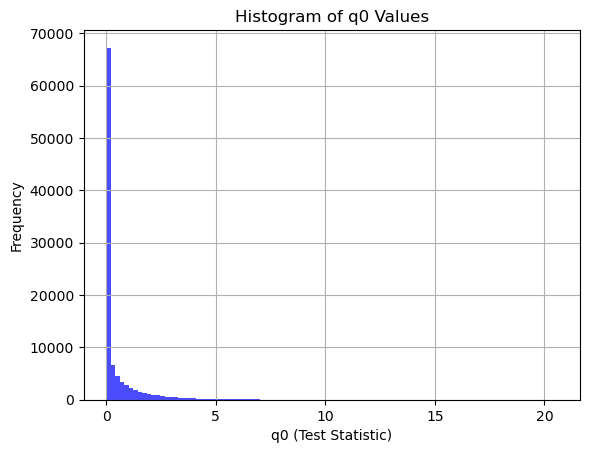

In [7]:
q0 = discovery_statistics(n,m,s,tau)

# Plotting the histogram
plt.hist(q0, bins=100, color='blue', alpha=0.7)
plt.xlabel('q0 (Test Statistic)')
plt.ylabel('Frequency')
plt.title('Histogram of q0 Values')
plt.grid(True)
plt.show()

One interesting thing that you'll notice here is that if you filter out all the experiments for which $\hat{\mu}<0$ you'll get close of half of the total experiments. You can check this in the next block.

In [8]:
(mu_hat(n,m,s,tau) < 0).sum() / nexp  # Fraction of mu_hat values that are zero

np.float64(0.4963)

To understand why is happens, we should first understand Wilks' theorem. Around the maximum for $\hat{\mu}\geq 0$ we have,

$$L(\mu) \approx l(\hat{\mu}) + \frac{1}{2}(\mu-\hat{\mu})^2 l''(\hat{\mu})$$

which means that the test statistics around $\mu=0$,

$$q_0 = -2\ln\lambda = -\hat{\mu}^2 l''(\hat{\mu})$$

We know that $\sigma^2_\mu = -1/l''$ which gives us,

$$q_0 = -2\ln\lambda = \frac{\hat{\mu}^2}{\sigma^2_\mu} = Z^2$$

and thus $q_0$ should follow $\chi_1^2$ distribution for $\hat{\mu}\geq 0$. Now when there is no signal, and we are solely looking at background event, statistical fluctuation would give some events above the expectation giving a positive test statistics while some below it giving a negative test statistics. The probability of seeing both these cases is $1/2$, but since we set $q_0=0$ for the negative fluctuations the total distribution must be,

$$f(q_0) = \frac{1}{2}\delta(q_0) + \frac{1}{2}f_{\chi_1^2}(q_0)$$

While we saw that for about half of the experiments $q_0$ did show a Dirac delta distribution, we should check if the other half follow chi square distribution of degree 1! To see this we keep only the $q_0 > 0$ values and fit with a chi square distribution to estimate the degree of freedom! Just run the code block below to see.

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 95.67                      │              Nfcn = 18               │
│ EDM = 4.86e-07 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

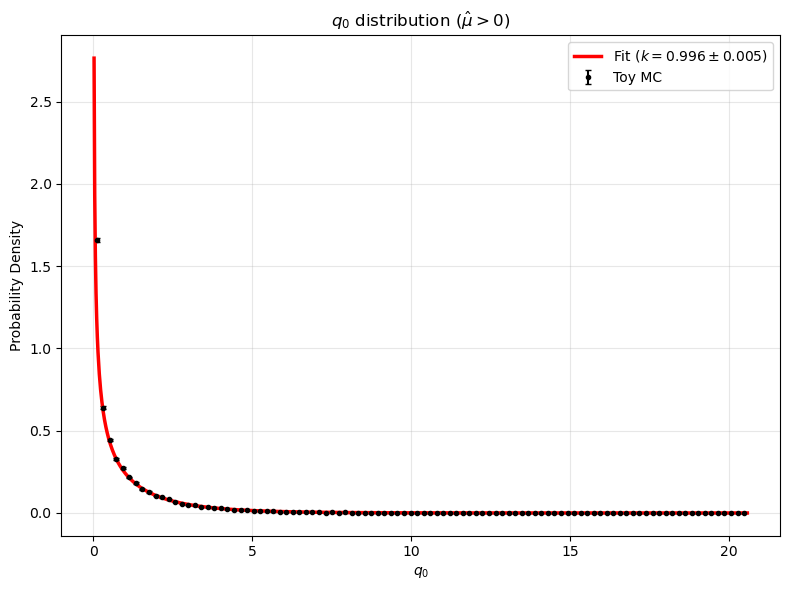

In [9]:
# -------------------------------------------------
# Select only q0 > 0
# -------------------------------------------------
q = np.asarray(q0[q0 > 0])

# -------------------------------------------------
# Histogram
# -------------------------------------------------
nbins = 100

density, edges = np.histogram(q, bins=nbins, density=True)
counts, _ = np.histogram(q, bins=edges)

centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

# Uncertainty on the normalized density
errors = np.sqrt(np.maximum(counts, 1)) / (len(q) * widths)

# -------------------------------------------------
# Bin-averaged model
# -------------------------------------------------
def model(edges, k):
    left = edges[:-1]
    right = edges[1:]

    # Average PDF over each bin
    return (chi2.cdf(right, df=k) - chi2.cdf(left, df=k)) / (right - left)

# -------------------------------------------------
# Chi-square function
# -------------------------------------------------
def chi2_cost(k):
    expected = model(edges, k)

    mask = errors > 0

    return np.sum(
        ((density[mask] - expected[mask]) / errors[mask]) ** 2
    )

# -------------------------------------------------
# Fit
# -------------------------------------------------
mt = Minuit(chi2_cost, k=1.0)

mt.limits["k"] = (0.2, 5.0)
mt.errordef = Minuit.LEAST_SQUARES

mt.migrad()
mt.hesse()

# -------------------------------------------------
# Results
# -------------------------------------------------
print(mt)

print(f"\nDegrees of freedom = {mt.values['k']:.5f} ± {mt.errors['k']:.5f}")

chi2_fit = mt.fval
ndof = len(density) - mt.nfit

print(f"chi2 = {chi2_fit:.2f}")
print(f"ndof = {ndof}")
print(f"chi2/ndof = {chi2_fit/ndof:.3f}")

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(8,6))

plt.errorbar(
    centers,
    density,
    yerr=errors,
    fmt='o',
    color='black',
    markersize=3,
    capsize=2,
    label='Toy MC'
)

# Smooth theoretical curve
x = np.linspace(0, edges[-1], 1000)

plt.plot(
    x,
    chi2.pdf(x, df=mt.values["k"]),
    color='red',
    lw=2.5,
    label=rf'Fit ($k={mt.values["k"]:.3f}\pm{mt.errors["k"]:.3f}$)'
)

plt.xlabel(r"$q_0$")
plt.ylabel("Probability Density")
plt.title(r"$q_0$ distribution ($\hat{\mu}>0$)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Upper Limit on Signal Strength $(\mu=\mu_0)$

Having discussed the discovery test statistic, let us now consider the complementary problem of setting an upper limit on the signal strength. Rather than asking whether the background-only hypothesis can be rejected, we now ask:

> **How large could the signal strength be while remaining consistent with the observed data?**

To answer this question, we test a sequence of signal-strength hypotheses, $\mu=\mu_0$, using the profile likelihood ratio. If the data favour a signal strength smaller than the tested value, i.e. $\hat{\mu}\leq\mu$ then the tested hypothesis may be disfavoured and contributes to the test statistic. On the other hand, if $\hat{\mu} > \mu$ the observed data contain at least as much signal as the tested hypothesis predicts. Such upward fluctuations do not constitute evidence against the hypothesis, and therefore the test statistic is defined to be zero.

The one-sided test statistic used for upper-limit calculations is therefore,

$$q_{\mu} = \begin{cases} - 2\ln\lambda(\mu) & \hat{\mu}\leq \mu\\ 0 & \hat{\mu}>\mu\end{cases}$$

Write down the upper limit statistics.


In [33]:
def upper_limit_statistics(mu,n,m,s,tau):
    test_stat = test_statistics(mu,n,m,s,tau)
    mu_h = mu_hat(n,m,s,tau)
    test_stat[mu_h > mu] = 0
    return test_stat

Now consider a similar setup as before with 100000 experiments with $b=9000,\tau=1,s=60,\mu=1$. Generate the SR and CR samples.

In [54]:
nexp = 100000
b = 9000
tau = 1
s = 60
mu = 1

mean_CR = b * tau  # Poisson mean for the CR
mean_SR = mu*s + b        # Poisson mean for the SR

# Generate Poisson-distributed data
n = np.random.poisson(mean_SR, size=nexp)  # Data set 1: mean = b * tau
m = np.random.poisson(mean_CR, size=nexp)  # Data set 2: mean = b

For $\mu_0=\mu$ plot $q_0$ distribution.

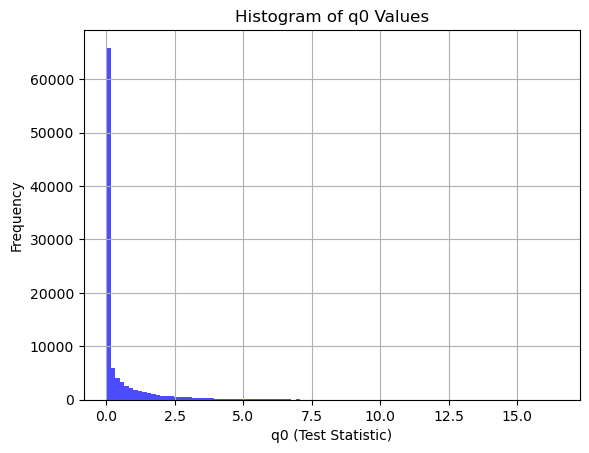

In [55]:
q0 = upper_limit_statistics(mu,n,m,s,tau)

# Plotting the histogram
plt.hist(q0, bins=100, color='blue', alpha=0.7)
plt.xlabel('q0 (Test Statistic)')
plt.ylabel('Frequency')
plt.title('Histogram of q0 Values')
plt.grid(True)
plt.show()

Like before you should get a distribution,

$$f(q_\mu) = \frac{1}{2}\delta(q_\mu) + \frac{1}{2}f_{\chi_1^2}(q_\mu)$$

Again the reason is similar to what we argued before. To check this first check that indeed $\hat{\mu}>\mu$ constitutes about half of the experiments.

In [56]:
(mu_hat(n,m,s,tau) > mu).sum() / nexp  # Fraction of mu_hat values that are zero

np.float64(0.49955)

And then you can check that the chi square distribution component has $k=1$.

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 93.01                      │              Nfcn = 18               │
│ EDM = 8.9e-10 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──────

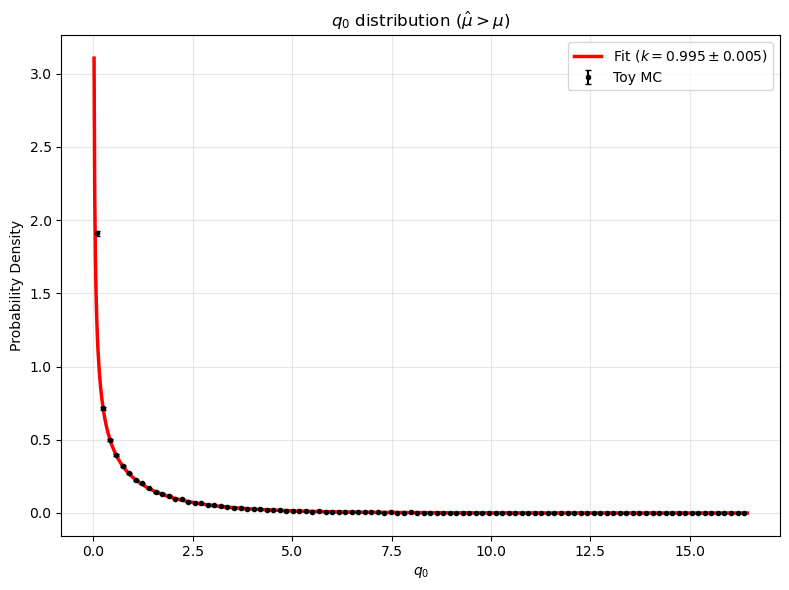

In [57]:
# -------------------------------------------------
# Select only q0 > 0
# -------------------------------------------------
q = np.asarray(q0[q0 > 0])

# -------------------------------------------------
# Histogram
# -------------------------------------------------
nbins = 100

density, edges = np.histogram(q, bins=nbins, density=True)
counts, _ = np.histogram(q, bins=edges)

centers = 0.5 * (edges[:-1] + edges[1:])
widths = np.diff(edges)

# Uncertainty on the normalized density
errors = np.sqrt(np.maximum(counts, 1)) / (len(q) * widths)

# -------------------------------------------------
# Bin-averaged model
# -------------------------------------------------
def model(edges, k):
    left = edges[:-1]
    right = edges[1:]

    # Average PDF over each bin
    return (chi2.cdf(right, df=k) - chi2.cdf(left, df=k)) / (right - left)

# -------------------------------------------------
# Chi-square function
# -------------------------------------------------
def chi2_cost(k):
    expected = model(edges, k)

    mask = errors > 0

    return np.sum(
        ((density[mask] - expected[mask]) / errors[mask]) ** 2
    )

# -------------------------------------------------
# Fit
# -------------------------------------------------
mt = Minuit(chi2_cost, k=1.0)

mt.limits["k"] = (0.2, 5.0)
mt.errordef = Minuit.LEAST_SQUARES

mt.migrad()
mt.hesse()

# -------------------------------------------------
# Results
# -------------------------------------------------
print(mt)

print(f"\nDegrees of freedom = {mt.values['k']:.5f} ± {mt.errors['k']:.5f}")

chi2_fit = mt.fval
ndof = len(density) - mt.nfit

print(f"chi2 = {chi2_fit:.2f}")
print(f"ndof = {ndof}")
print(f"chi2/ndof = {chi2_fit/ndof:.3f}")

# -------------------------------------------------
# Plot
# -------------------------------------------------
plt.figure(figsize=(8,6))

plt.errorbar(
    centers,
    density,
    yerr=errors,
    fmt='o',
    color='black',
    markersize=3,
    capsize=2,
    label='Toy MC'
)

# Smooth theoretical curve
x = np.linspace(0, edges[-1], 1000)

plt.plot(
    x,
    chi2.pdf(x, df=mt.values["k"]),
    color='red',
    lw=2.5,
    label=rf'Fit ($k={mt.values["k"]:.3f}\pm{mt.errors["k"]:.3f}$)'
)

plt.xlabel(r"$q_0$")
plt.ylabel("Probability Density")
plt.title(r"$q_0$ distribution ($\hat{\mu}>\mu$)")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

Now lets say your SR count is 9003 and CR count is 8990. Take $\mu_0\in[0,10\mu]$. You know the distribution that the test statistics would follow by now, so use that and calculate $p$-value for different $\mu_0$ and check for which $\mu_0$ the $p$-value is smaller than $0.05$. Use the last block to plot it!

In [ ]:
mu0 = np.linspace(0, 10*mu, 1000)

pvals = []

for mui in mu0:
    q = upper_limit_statistics(mui, np.array([9003]), np.array([8990]), s, tau)

    if q <= 0:
        p = 1.0
    else:
        p = 0.5 * chi2.sf(q, df=1)
        p = p.item()

    pvals.append(p)

pvals = np.array(pvals)


In [86]:
idx = np.argmin(np.abs(pvals - 0.05))

print(f"95% CL upper limit: mu = {mu0[idx]:.3f}")

95% CL upper limit: mu = 3.894


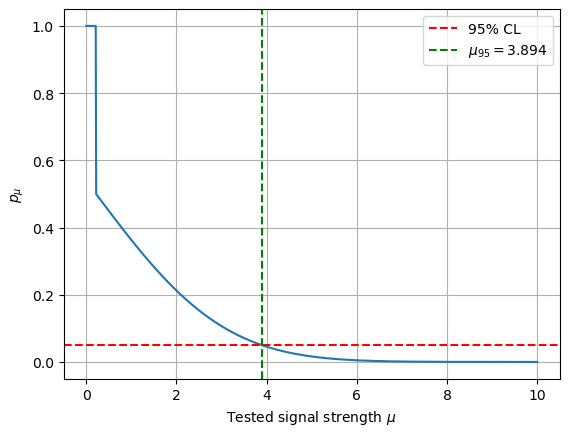

In [ ]:
plt.plot(mu0, pvals)
plt.axhline(0.05, color='red', ls='--', label='95% CL')
plt.axvline(mu0[idx], color='green', ls='--',
            label=rf'$\mu_{{95}}={mu0[idx]:.3f}$')

plt.xlabel(r'Tested signal strength $\mu$')
plt.ylabel(r'$p_\mu$')
plt.legend()
plt.grid(True)
plt.show()